## Classification Example on the MNIST Dataset

**Note: Please read Lab instructions in parallel to these steps. Reading book chapter (chapter 3: Classification) will also be very helpful for you to understand these steps. Also, run each cell individually to understand the setp and the output.**

In [1]:
import sys

assert sys.version_info >= (3, 7)

In [2]:
from packaging import version
import sklearn

assert version.parse(sklearn.__version__) >= version.parse("1.0.1")

In [3]:
import matplotlib.pyplot as plt

plt.rc('font', size=14)
plt.rc('axes', labelsize=14, titlesize=14)
plt.rc('legend', fontsize=14)
plt.rc('xtick', labelsize=10)
plt.rc('ytick', labelsize=10)

Create the `images/classification` folder (if it doesn't already exist)

In [4]:
from pathlib import Path

IMAGES_PATH = Path() / "images" / "classification"
IMAGES_PATH.mkdir(parents=True, exist_ok=True)

def save_fig(fig_id, tight_layout=True, fig_extension="png", resolution=300):
    path = IMAGES_PATH / f"{fig_id}.{fig_extension}"
    if tight_layout:
        plt.tight_layout()
    plt.savefig(path, format=fig_extension, dpi=resolution)

##Task 1: Fetch the MNIST dataset
**Import Necessary Libraries**

In [5]:
import numpy as np  # Library for numerical operations and working with arrays
import matplotlib.pyplot as plt  # Library for creating static, animated, and interactive visualizations

from sklearn.model_selection import train_test_split  # Function to split datasets into training and testing sets
from sklearn.preprocessing import StandardScaler  # Scaler for standardizing features by removing the mean and scaling to unit variance
from sklearn.model_selection import cross_val_score  # Function to evaluate a model using cross-validation
from sklearn.model_selection import GridSearchCV  # Function to perform an exhaustive search over specified parameter values for an estimator

from sklearn.datasets import fetch_openml  # Function to fetch datasets from OpenML, such as the MNIST dataset
from sklearn.linear_model import SGDClassifier  # Stochastic Gradient Descent classifier for training linear models
from sklearn.metrics import confusion_matrix, accuracy_score  # Functions to compute evaluation metrics for classification models

**Load the MNIST Dataset**

In [6]:
import numpy as np
import keras
from keras.datasets import mnist as keras_mnist


(X_train_raw, y_train_raw), (X_test_raw, y_test_raw) = keras_mnist.load_data()

X = np.concatenate((X_train_raw, X_test_raw), axis=0).reshape(-1, 28 * 28)
y = np.concatenate((y_train_raw, y_test_raw), axis=0).astype(str)


class MNISTData:
    def __init__(self, data, target):
        self.data = data
        self.target = target
        self.DESCR = "MNIST dataset loaded via Keras workaround."
    def keys(self):
        return ['data', 'target', 'DESCR']

# Create the object the rest of the lab is looking for
mnist = MNISTData(X, y)

print("Workaround complete. Data loaded successfully!")

11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
Workaround complete. Data loaded successfully!


In [7]:

print(mnist.DESCR)

MNIST dataset loaded via Keras workaround.


In [8]:
mnist.keys()  #we only use data and target in this notebook

['data', 'target', 'DESCR']

In [9]:
X, y = mnist.data, mnist.target
X

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]], shape=(70000, 784), dtype=uint8)

In [10]:
y

array(['5', '0', '4', ..., '4', '5', '6'], shape=(70000,), dtype='<U3')

In [11]:
# Display the shape of the data and labels
print(X.shape, y.shape)

(70000, 784) (70000,)


**Visualize the Data**

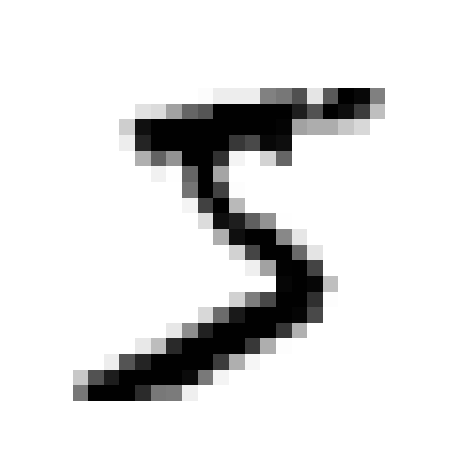

In [12]:
import matplotlib.pyplot as plt


def plot_digit(image_data):
    image = image_data.reshape(28, 28)
    plt.imshow(image, cmap="binary") # to get a grayscale color map where 0 is white and 255 is black
    plt.axis("off")

some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")  # extra code
plt.show()

In [13]:
print("The first digit in the Data set is: ", y[0]) # check in the label dataset

The first digit in the Data set is:  5


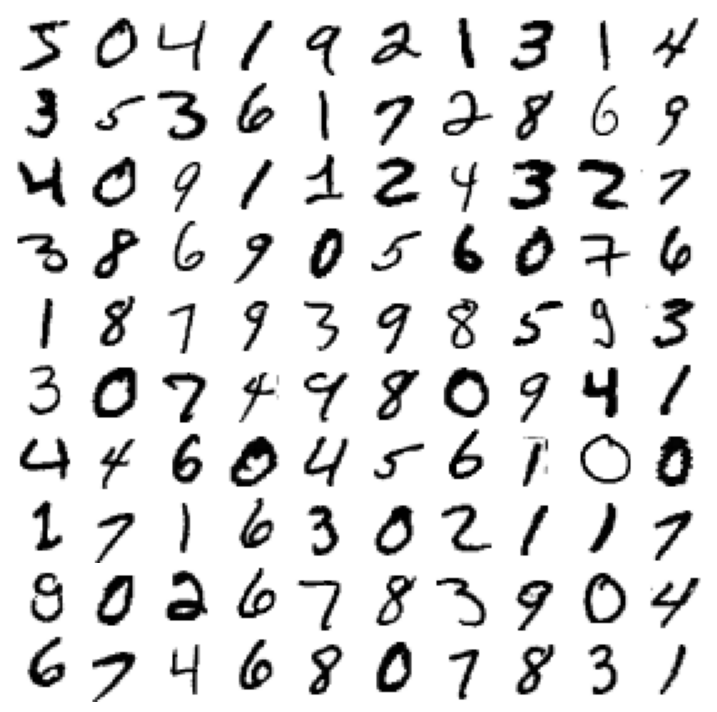

In [14]:
# This cell generates and saves Figure 3–2
plt.figure(figsize=(9, 9))
for idx, image_data in enumerate(X[:100]):
    plt.subplot(10, 10, idx + 1)
    plot_digit(image_data)
plt.subplots_adjust(wspace=0, hspace=0)
save_fig("more_digits_plot", tight_layout=False)
plt.show()

**Split the Data into Training and Test Sets**

In [15]:
X_train, X_test, y_train, y_test = X[:60000], X[60000:], y[:60000], y[60000:]

In [16]:
y_train_5 = (y_train == '5')  # True for all 5s, False for all other digits
y_test_5 = (y_test == '5')

# Training a Binary Classifier

**Stochastic Gradient Descent (SGD) Classifier**

In [17]:
# Import the SGDClassifier from Scikit-Learn's linear model module
from sklearn.linear_model import SGDClassifier

# Create an instance of the SGDClassifier with a specified random state for reproducibility
# The random state ensures that the results are consistent across different runs
sgd_clf = SGDClassifier(random_state=42)


# Fit the SGDClassifier to the training data
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
sgd_clf.fit(X_train, y_train_5)

,loss,'hinge'
,penalty,'l2'
,alpha,0.0001
,l1_ratio,0.15
,fit_intercept,True
,max_iter,1000
,tol,0.001
,shuffle,True
,verbose,0
,epsilon,0.1
,n_jobs,None


The following code is to use the trained SGD classifier to make a prediction on a single example, "some_digit".

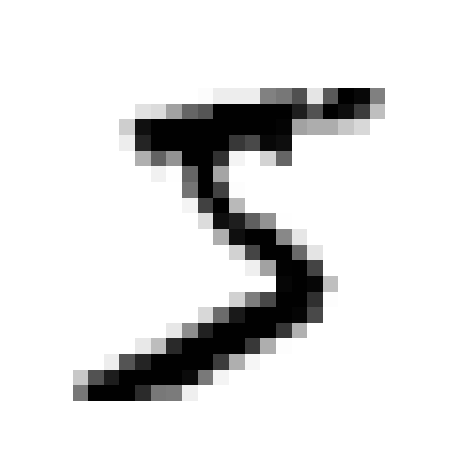

In [18]:
some_digit = X[0] # display very first didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

In [19]:
sgd_clf.predict([some_digit])

array([ True])

Let's check another image of the dataset, for example, 10th image.

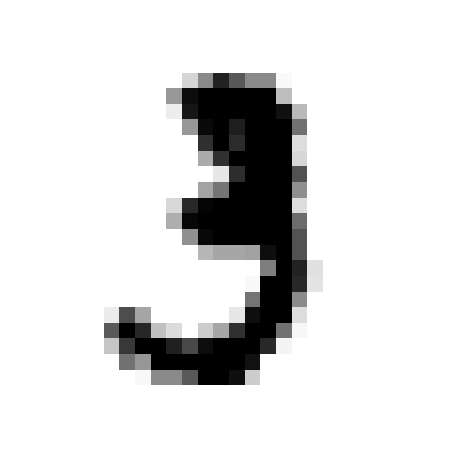

In [20]:
some_digit = X[10] # display 10th didgit in the dataset
plot_digit(some_digit)
save_fig("some_digit_plot")
plt.show()

Predict this image using our trained classifier:

In [21]:
sgd_clf.predict([some_digit])

array([False])

In [22]:
# Examples of digits from the dataset
some_digits = X[:5]

# Make predictions on the multiple examples
predictions = sgd_clf.predict(some_digits)

# Display the predictions
print("Predictions for some_digits:", predictions)


Predictions for some_digits: [ True False False False False]


##Measuring Accuracy Using Cross-Validation

In [23]:
from sklearn.model_selection import cross_val_score # Import the cross_val_score function from Scikit-Learn


# Perform 3-fold cross-validation on the SGD classifier
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'scoring="accuracy"' specifies that we want to calculate the accuracy score
cross_val_score(sgd_clf, X_train, y_train_5, cv=3, scoring="accuracy")

# Display the cross-validation accuracy scores
#print("Cross-validation accuracy:", cross_val_score)

array([0.95035, 0.96035, 0.9604 ])

**Implementing Cross-Validation**

In [24]:
from sklearn.model_selection import StratifiedKFold
from sklearn.base import clone

skfolds = StratifiedKFold(n_splits=3)  # add shuffle=True if the dataset is not
                                       # already shuffled
for train_index, test_index in skfolds.split(X_train, y_train_5):
    clone_clf = clone(sgd_clf)
    X_train_folds = X_train[train_index]
    y_train_folds = y_train_5[train_index]
    X_test_fold = X_train[test_index]
    y_test_fold = y_train_5[test_index]

    clone_clf.fit(X_train_folds, y_train_folds)
    y_pred = clone_clf.predict(X_test_fold)
    n_correct = sum(y_pred == y_test_fold)
    print(n_correct / len(y_pred))

0.95035
0.96035
0.9604


In [25]:
from sklearn.dummy import DummyClassifier

dummy_clf = DummyClassifier()
dummy_clf.fit(X_train, y_train_5)
print(any(dummy_clf.predict(X_train))) # it prints False: which means no 5s detected

False


In [26]:
cross_val_score(dummy_clf, X_train, y_train_5, cv=3, scoring="accuracy")

array([0.90965, 0.90965, 0.90965])

## Confusion Matrix

In [27]:
# Import cross_val_predict function from Scikit-Learn
from sklearn.model_selection import cross_val_predict

# Generate cross-validated predictions for the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
y_train_pred = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3)

In [28]:
# Import confusion_matrix function from Scikit-Learn
from sklearn.metrics import confusion_matrix

# Compute the confusion matrix to evaluate the classifier's performance
# 'y_train_5' are the actual labels
# 'y_train_pred' are the predicted labels from cross-validation
cm = confusion_matrix(y_train_5, y_train_pred)
#cm

In [29]:
# Display the confusion matrix
print(cm)

[[53892   687]
 [ 1891  3530]]


In [30]:
# Pretend we reached perfection by setting the predicted labels equal to the true labels
y_train_perfect_predictions = y_train_5

# Compute the confusion matrix with perfect predictions
# The confusion matrix should show all true positives and true negatives, with no false positives or false negatives
confusion_matrix(y_train_5, y_train_perfect_predictions)

array([[54579,     0],
       [    0,  5421]])

## Precision and Recall

In [31]:
# Import precision_score and recall_score from Scikit-Learn
from sklearn.metrics import precision_score, recall_score


# Compute the precision score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
precision = precision_score(y_train_5, y_train_pred)  # # Calculate precision: TP / (FP + TP) that is == 3530 / (687 + 3530)
print("Precision:", precision)

Precision: 0.8370879772350012


In [32]:
#To compute the precision manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[0, 1]' is FP
precision_manual = cm[1, 1] / (cm[0, 1] + cm[1, 1])
print("Manual precision calculation:", precision_manual) # manual precision calucltion from the confusion matrix

Manual precision calculation: 0.8370879772350012


In [33]:
# Compute the recall score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
recall = recall_score(y_train_5, y_train_pred)  # Calculate recall: TP / (FN + TP)
print("Recall:", recall)

Recall: 0.6511713705958311


In [34]:
# To compute the recall manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN
recall_manual = cm[1, 1] / (cm[1, 0] + cm[1, 1])
print("Manual recall calculation:", recall_manual) # manual recall calucltion from the confusion matrix

Manual recall calculation: 0.6511713705958311


**F1 Score:**

In [35]:
# Import the f1_score function from Scikit-Learn
from sklearn.metrics import f1_score

# Compute the F1 Score
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_train_pred' are the predicted labels from the classifier
f1 = f1_score(y_train_5, y_train_pred)  # Calculate the F1 Score using the precision and recall
print("F1 Score:", f1)

F1 Score: 0.7325171197343847


In [36]:
# To compute the F1 Score manually using the confusion matrix
# 'cm[1, 1]' is TP, 'cm[1, 0]' is FN, 'cm[0, 1]' is FP
# extra code – this cell also computes the f1 score
f1_manual = cm[1, 1] / (cm[1, 1] + (cm[1, 0] + cm[0, 1]) / 2)
print("Manual F1 Score calculation:", f1_manual)

Manual F1 Score calculation: 0.7325171197343847


In [37]:

from sklearn.metrics import classification_report

# Confusion Matrix
print("Confusion Matrix:")
print(cm)

# Classification Report
class_report = classification_report(y_train_5, y_train_pred)
print("Classification Report:")
print(class_report)

Confusion Matrix:
[[53892   687]
 [ 1891  3530]]
Classification Report:
              precision    recall  f1-score   support

       False       0.97      0.99      0.98     54579
        True       0.84      0.65      0.73      5421

    accuracy                           0.96     60000
   macro avg       0.90      0.82      0.85     60000
weighted avg       0.95      0.96      0.95     60000



## Precision/Recall Trade-off
The purpose of following codes is to demonstrate how changing the decision threshold affects the classifier's predictions.

In [38]:
some_digit = X[0] # check for 1st didgit in the dataset, please feel free to check for other digits as well

# Get the decision scores for a single example
# 'sgd_clf' is the trained SGD classifier
# 'decision_function' returns the distance of the samples to the decision boundary
y_scores = sgd_clf.decision_function([some_digit]) #
print("Decision Scores:", y_scores)

Decision Scores: [2164.22030239]


**Using a Threshold of 0**

In [39]:
# Apply a decision threshold of 0
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 0
y_some_digit_pred = (y_scores > threshold)
print("Digit prediction based on Decision Score threshold:", y_some_digit_pred)

Digit prediction based on Decision Score threshold: [ True]


In [40]:
# Shows that y_scores > 0 produces the same result as
#              calling predict()
y_scores > 0

array([ True])

**Using a Threshold of 3000**

In [41]:
# Apply a decision threshold of 3000
# Predict whether 'some_digit' is a positive class (True) or not (False)
threshold = 3000
y_some_digit_pred = (y_scores > threshold)
y_some_digit_pred

array([False])

In [42]:
# Perform cross-validation to obtain the decision scores for each instance in the training set
# 'sgd_clf' is the trained SGD classifier
# 'X_train' is the feature matrix for the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="decision_function"' specifies that we want to get the decision scores instead of class labels
y_scores = cross_val_predict(sgd_clf, X_train, y_train_5, cv=3,
                             method="decision_function")

# 'y_scores' will contain the decision scores for each instance in the training set
print(y_scores)  # Example output: array([1200.5, -500.2, 800.3, ...])

[  1200.93051237 -26883.79202424 -33072.03475406 ...  13272.12718981
  -7258.47203373 -16877.50840447]


**Precision/Recall Trade-off Curve**

In [43]:
# Import precision_recall_curve from Scikit-Learn
from sklearn.metrics import precision_recall_curve

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
precisions, recalls, thresholds = precision_recall_curve(y_train_5, y_scores)


In [44]:
print("Current Threshold is set:", threshold)

Current Threshold is set: 3000


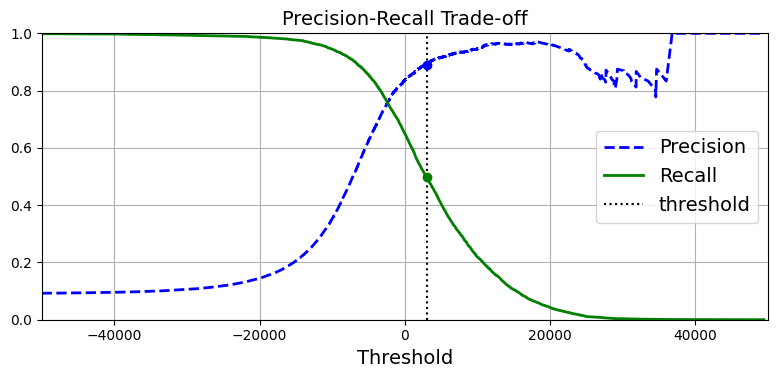

In [45]:
plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

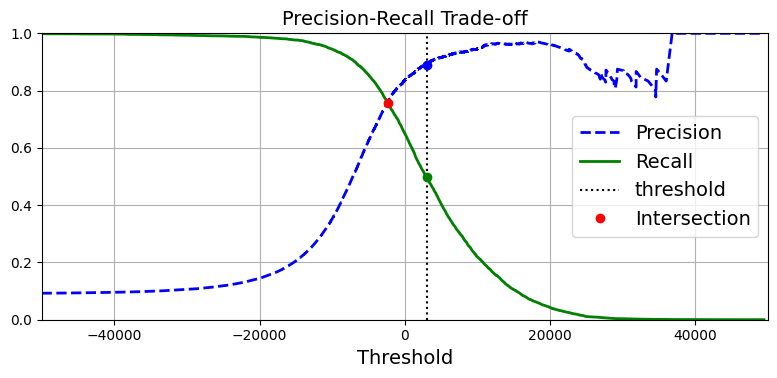

In [46]:
# Highlight the Intersection Point of Precision and Recall


# Find the index where precision and recall are closest to each other
diff = np.abs(precisions - recalls)
min_diff_index = np.argmin(diff)


plt.figure(figsize=(8, 4))  # extra code – it's not needed, just formatting
plt.plot(thresholds, precisions[:-1], "b--", label="Precision", linewidth=2)
plt.plot(thresholds, recalls[:-1], "g-", label="Recall", linewidth=2)
plt.vlines(threshold, 0, 1.0, "k", "dotted", label="threshold")

# extra code – this section just beautifies and saves Figure 3–5
idx = (thresholds >= threshold).argmax()  # first index ≥ threshold # Find the first index where threshold is greater than or equal to the chosen threshold
plt.plot(thresholds[idx], precisions[idx], "bo") # Highlight the precision at the chosen threshold
plt.plot(thresholds[idx], recalls[idx], "go") # Highlight the recall at the chosen threshold
plt.plot(thresholds[min_diff_index], precisions[min_diff_index], "ro", label="Intersection") # Highlight the intersection point
plt.axis([-50000, 50000, 0, 1])
plt.grid()
plt.xlabel("Threshold")
plt.legend(loc="center right")
plt.title("Precision-Recall Trade-off")
save_fig("precision_recall_vs_threshold_plot")

plt.show()

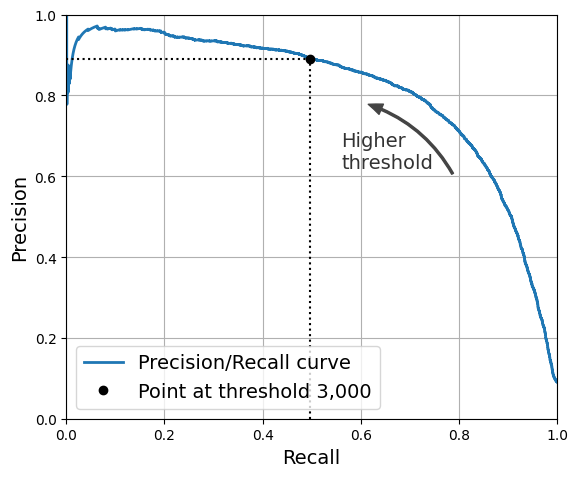

In [47]:
import matplotlib.patches as patches  # For the curved arrow

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls, precisions, linewidth=2, label="Precision/Recall curve")

# extra code – just beautifies and saves Figure 3–6
plt.plot([recalls[idx], recalls[idx]], [0., precisions[idx]], "k:")
plt.plot([0.0, recalls[idx]], [precisions[idx], precisions[idx]], "k:")
plt.plot([recalls[idx]], [precisions[idx]], "ko",
         label="Point at threshold 3,000")
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.79, 0.60), (0.61, 0.78),
    connectionstyle="arc3,rad=.2",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.56, 0.62, "Higher\nthreshold", color="#333333")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("precision_vs_recall_plot")

plt.show()

Suppose you decided to aim for 90% precision. You could use the first plot to find the threshold you need to use, but that is not very precise. Alternatively you search for the lowest threshold that gives you at least 90% precision.

In [48]:
indices_above_90 = np.where(precisions[:len(thresholds)] >= 0.90)[0]

if len(indices_above_90) > 0:
    # Get the first index where precision is >= 0.90
    idx_for_90_precision = indices_above_90[0]
else:
    # If no precision >= 0.90 is found, select the last valid index
    # This is a fallback to prevent IndexError if no threshold meets the criteria
    idx_for_90_precision = len(thresholds) - 1

# Ensure the index is within bounds, especially for edge cases
idx_for_90_precision = min(idx_for_90_precision, len(thresholds) - 1)
idx_for_90_precision = max(idx_for_90_precision, 0)

threshold_for_90_precision = thresholds[idx_for_90_precision]
threshold_for_90_precision

np.float64(3370.0194991439557)

In [49]:
y_train_pred_90 = (y_scores >= threshold_for_90_precision)

In [50]:
precision_score(y_train_5, y_train_pred_90)

0.9000345901072293

In [51]:
recall_at_90_precision = recall_score(y_train_5, y_train_pred_90)
recall_at_90_precision

0.4799852425751706

## The ROC Curve

In [52]:
from sklearn.metrics import roc_curve # Import roc_curve function from Scikit-Learn


# Calculate the ROC curve
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores' are the decision scores obtained from the classifier
fpr, tpr, thresholds = roc_curve(y_train_5, y_scores)

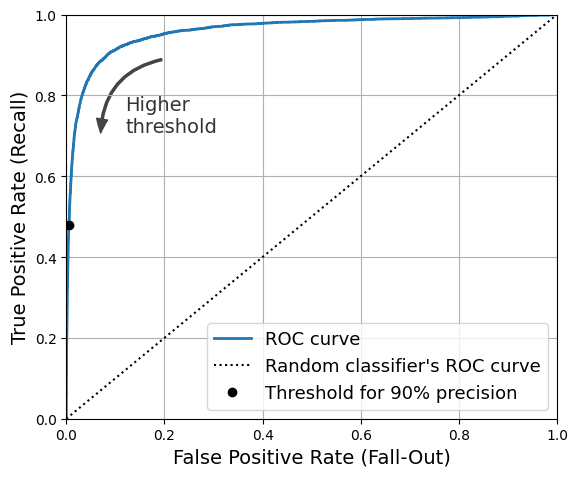

In [53]:
# Find the index of the threshold that gives 90% precision
# 'thresholds' contains the threshold values used to calculate fpr and tpr
# 'threshold_for_90_precision' is a predefined threshold that corresponds to 90% precision
idx_for_threshold_at_90 = (thresholds <= threshold_for_90_precision).argmax()
tpr_90, fpr_90 = tpr[idx_for_threshold_at_90], fpr[idx_for_threshold_at_90]

plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting
plt.plot(fpr, tpr, linewidth=2, label="ROC curve")
plt.plot([0, 1], [0, 1], 'k:', label="Random classifier's ROC curve")
plt.plot([fpr_90], [tpr_90], "ko", label="Threshold for 90% precision")

# extra code – just beautifies and saves Figure 3–7
plt.gca().add_patch(patches.FancyArrowPatch(
    (0.20, 0.89), (0.07, 0.70),
    connectionstyle="arc3,rad=.4",
    arrowstyle="Simple, tail_width=1.5, head_width=8, head_length=10",
    color="#444444"))
plt.text(0.12, 0.71, "Higher\nthreshold", color="#333333")
plt.xlabel('False Positive Rate (Fall-Out)')
plt.ylabel('True Positive Rate (Recall)')
plt.grid()
plt.axis([0, 1, 0, 1])
plt.legend(loc="lower right", fontsize=13)
save_fig("roc_curve_plot")

plt.show()

**Area Under the ROC Curve (AUC-ROC)**

In [54]:
from sklearn.metrics import roc_auc_score # Import the roc_auc_score function from Scikit-Learn

# Calculate the AUC-ROC score
auc_roc= roc_auc_score(y_train_5, y_scores)

# Display the AUC-ROC score
print("AUC-ROC Score:", auc_roc)

AUC-ROC Score: 0.9604938554008616


##RandomForestClassifier for the same dataset

In [55]:
from sklearn.ensemble import RandomForestClassifier # Import the RandomForestClassifier from Scikit-Learn

# Create an instance of the Random Forest Classifier
forest_clf = RandomForestClassifier(random_state=42)

In [56]:
# Perform cross-validation to obtain probability predictions for each instance in the training set
# 'forest_clf' is the Random Forest classifier
# 'X_train' is the feature matrix of the training set
# 'y_train_5' is the target vector indicating whether each digit is a 5 (binary classification)
# 'cv=3' specifies 3-fold cross-validation
# 'method="predict_proba"' specifies that we want to get the probability predictions instead of class labels
y_probas_forest = cross_val_predict(forest_clf, X_train, y_train_5, cv=3,
                                    method="predict_proba")

In [57]:
# Display the first two probability predictions
y_probas_forest[:2]

array([[0.11, 0.89],
       [0.99, 0.01]])

In [58]:
y_scores_forest = y_probas_forest[:, 1]

# Calculate precision and recall for different threshold values
# 'y_train_5' are the actual labels indicating whether each digit is a 5 (binary classification)
# 'y_scores_forest' are the scores (probabilities) for the positive class
precisions_forest, recalls_forest, thresholds_forest = precision_recall_curve(
    y_train_5, y_scores_forest)

In [59]:
print("Precision Forest=", precisions_forest)
print("Recall Forest=", recalls_forest)
print("Threshold Forest=", thresholds_forest)

Precision Forest= [0.09035    0.15601796 0.21697018 0.2782198  0.3359375  0.39168474
 0.4434341  0.49221099 0.53883011 0.58103448 0.62384152 0.65814579
 0.69354839 0.72090213 0.74856904 0.77310803 0.79370733 0.81468478
 0.83029737 0.84566529 0.8605178  0.87232994 0.88209825 0.89121268
 0.90208833 0.90986159 0.9178634  0.92464178 0.93120086 0.93672255
 0.94127273 0.94605505 0.95223107 0.95618941 0.95927941 0.96257089
 0.96431961 0.96689629 0.96939365 0.97113522 0.97292032 0.975495
 0.97634069 0.9787572  0.98101519 0.98323571 0.98412375 0.98566455
 0.98719273 0.98773389 0.98974681 0.99050833 0.99129327 0.99186644
 0.99180858 0.99259582 0.99340804 0.99378606 0.99440841 0.99458239
 0.99474526 0.99514451 0.99555659 0.99622997 0.99618594 0.99638031
 0.9965661  0.99652605 0.99672462 0.99692938 0.99688393 0.99762031
 0.9981203  0.99809004 0.99832496 0.99828816 0.99825581 0.99821694
 0.99847793 0.99843309 0.99903038 0.99900498 0.99897119 0.99893692
 0.9989011  0.9996173  1.         1.         1

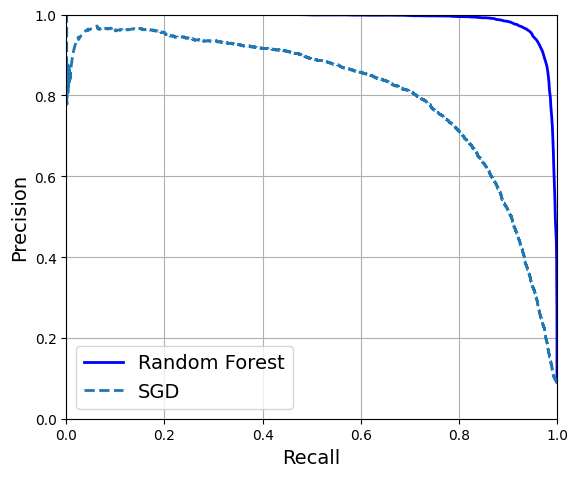

In [60]:
plt.figure(figsize=(6, 5))  # extra code – not needed, just formatting

plt.plot(recalls_forest, precisions_forest, "b-", linewidth=2,
         label="Random Forest")
plt.plot(recalls, precisions, "--", linewidth=2, label="SGD")

# extra code – just beautifies and saves Figure 3–8
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.axis([0, 1, 0, 1])
plt.grid()
plt.legend(loc="lower left")
save_fig("pr_curve_comparison_plot")

plt.show()

In [61]:
y_train_pred_forest = y_probas_forest[:, 1] >= 0.5  # positive proba ≥ 50%
f1_score(y_train_5, y_train_pred_forest)

0.9274509803921569

In [62]:
roc_auc_score(y_train_5, y_scores_forest)

0.9983436731328145

In [63]:
precision_score(y_train_5, y_train_pred_forest)

0.9897468089558485

In [64]:
recall_score(y_train_5, y_train_pred_forest)

0.8725327430363402

In [65]:
#For class report

# Classification Report SGD
#class_report_SGD = classification_report(y_train_5, y_train_pred)
#print("Classification Report of SGD:")
#print(class_report_SGD)


# Classification Report SGD
class_report_forest = classification_report(y_train_5, y_train_pred_forest)
print("Classification Report of Random Fdrest:")
print(class_report_forest)

Classification Report of Random Fdrest:
              precision    recall  f1-score   support

       False       0.99      1.00      0.99     54579
        True       0.99      0.87      0.93      5421

    accuracy                           0.99     60000
   macro avg       0.99      0.94      0.96     60000
weighted avg       0.99      0.99      0.99     60000



#Multiclass and Multioutput Classification (Optional (For Practice Only)

# SVM classifier
(for more detils see Chapt 5 of literature Book)

In [66]:
from sklearn.svm import SVC # Import the SVC (Support Vector Classifier) class from Scikit-Learn

# Create an instance of the SVM classifier
svm_clf = SVC(random_state=42)

# Train the SVM classifier on a subset of the training data (2000 instances)
svm_clf.fit(X_train[:2000], y_train[:2000])  # y_train, not y_train_5

,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'
,coef0,0.0
,shrinking,True
,probability,False
,tol,0.001
,cache_size,200
,class_weight,None
,verbose,False


In [67]:
# Predict the class of 'some_digit' using the trained SVM classifier
svm_predict = svm_clf.predict([some_digit])

print("Predicted class:", svm_predict)

Predicted class: ['5']


In [68]:
# Get the decision scores for 'some_digit' using the SVM classifier
# 'decision_function' returns the distance of the samples to the decision boundary
some_digit_scores = svm_clf.decision_function([some_digit])
print("Decision scores:", some_digit_scores.round(2))

Decision scores: [[ 3.79  0.73  6.06  8.3  -0.29  9.3   1.75  2.77  7.21  4.82]]


In [69]:
# Find the class with the highest decision score
class_id = some_digit_scores.argmax()
print("Class with the highest decision score:", class_id)

Class with the highest decision score: 5


In [70]:
# Get the classes used by the SVM classifier
classes = svm_clf.classes_
print("Classes:", classes)

Classes: ['0' '1' '2' '3' '4' '5' '6' '7' '8' '9']


In [71]:
# Find the predicted class for 'some_digit'
predicted_class = svm_clf.classes_[class_id]
print("Predicted class from decision scores:", predicted_class)

Predicted class from decision scores: 5


In [72]:
# hows how to get all 45 OvO scores if needed
svm_clf.decision_function_shape = "ovo"
some_digit_scores_ovo = svm_clf.decision_function([some_digit])
some_digit_scores_ovo.round(2)

array([[ 0.11, -0.21, -0.97,  0.51, -1.01,  0.19,  0.09, -0.31, -0.04,
        -0.45, -1.28,  0.25, -1.01, -0.13, -0.32, -0.9 , -0.36, -0.93,
         0.79, -1.  ,  0.45,  0.24, -0.24,  0.25,  1.54, -0.77,  1.11,
         1.13,  1.04,  1.2 , -1.42, -0.53, -0.45, -0.99, -0.95,  1.21,
         1.  ,  1.  ,  1.08, -0.02, -0.67, -0.14, -0.3 , -0.13,  0.25]])

Here is an exmaple of OvR classifier

In [73]:
from sklearn.multiclass import OneVsRestClassifier  # Import OneVsRestClassifier for OvR strategy

# Create an instance of OneVsRestClassifier with SVC as the base classifier
ovr_clf = OneVsRestClassifier(SVC(random_state=42))

# Train the One-vs-Rest classifier on a subset of the training data (2000 instances)
ovr_clf.fit(X_train[:2000], y_train[:2000])

# Predict the class of 'some_digit' using the trained One-vs-Rest classifier
ovr_prediction = ovr_clf.predict([some_digit])
print("Predicted class:", ovr_prediction)

# Get the number of estimators (one estimator for each class)
ovr_num_estimators = len(ovr_clf.estimators_)
print("Number of estimators:", ovr_num_estimators)


Predicted class: ['5']
Number of estimators: 10


Here is an exmaple of OvO classifier

In [74]:
from sklearn.multiclass import OneVsOneClassifier  # Import OneVsOneClassifier for OvO strategy

# Create an instance of OneVsOneClassifier with SVC as the base classifier
ovo_clf = OneVsOneClassifier(SVC(random_state=42))

# Train the One-vs-One classifier on a subset of the training data (2000 instances)
ovo_clf.fit(X_train[:2000], y_train[:2000])

# Predict the class of 'some_digit' using the trained One-vs-One classifier
prediction_ovo = ovo_clf.predict([some_digit])
print("Predicted class (OvO):", prediction_ovo)

# Get the number of estimators (one estimator for each pair of classes)
num_estimators_ovo = len(ovo_clf.estimators_)
print("Number of estimators (OvO):", num_estimators_ovo)


Predicted class (OvO): ['5']
Number of estimators (OvO): 45


Training an SGDClassifier on a multiclass dataset

In [75]:
sgd_clf = SGDClassifier(random_state=42)
sgd_clf.fit(X_train, y_train)
sgd_clf.predict([some_digit])

array(['3'], dtype='<U1')

Let's look at the scores that the SGD classifier assigned to each.

In [76]:
sgd_clf_scores = sgd_clf.decision_function([some_digit]).round()
print("Scores assigned to each class:", sgd_clf_scores)

Scores assigned to each class: [[-31893. -34420.  -9531.   1824. -22320.  -1386. -26189. -16148.  -4604.
  -12051.]]


In [77]:
cross_val_score(sgd_clf, X_train, y_train, cv=3, scoring="accuracy")

array([0.87365, 0.85835, 0.8689 ])

In [78]:
from sklearn.preprocessing import StandardScaler # Import the StandardScaler for scaling the input features

# Create an instance of StandardScaler
scaler = StandardScaler()

# Scale the training data
X_train_scaled = scaler.fit_transform(X_train.astype("float64"))

# Perform cross-validation on the scaled data to evaluate the classifier's performance
accuracy_scores = cross_val_score(sgd_clf, X_train_scaled, y_train, cv=3, scoring="accuracy")

# Display the accuracy scores
print("Cross-validation accuracy scores:", accuracy_scores)

Cross-validation accuracy scores: [0.8983 0.891  0.9018]


**Error Analysis**

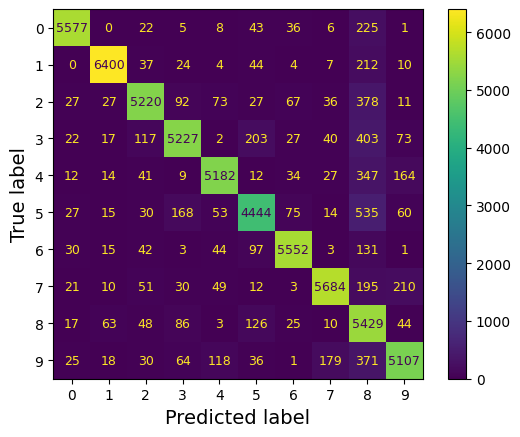

In [79]:
from sklearn.metrics import ConfusionMatrixDisplay # Import ConfusionMatrixDisplay for visualizing the confusion matrix

# Perform cross-validation to obtain predictions for each instance in the training set
y_train_pred = cross_val_predict(sgd_clf, X_train_scaled, y_train, cv=3)

plt.rc('font', size=9)  # extra code – make the text smaller

# Generate and display the confusion matrix
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred)
plt.show()

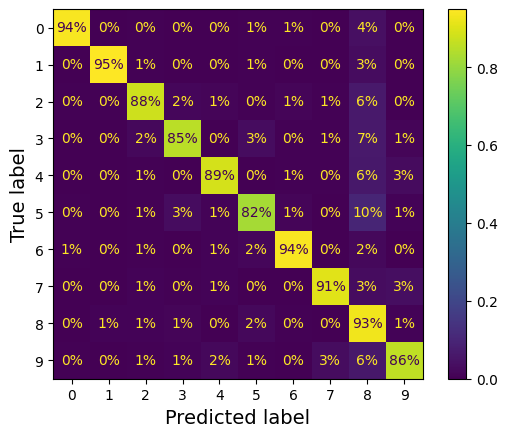

In [80]:
# Display a normalized confusion matrix where the values are represented as percentages rather than absolute counts.
# This can provide a clearer understanding of the classifier's performance across different classes by showing the proportion of correct and incorrect predictions for each class.
plt.rc('font', size=10)  # set the font size for the plot

# Generate and display the normalized confusion matrix
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        normalize="true", values_format=".0%")
plt.show()

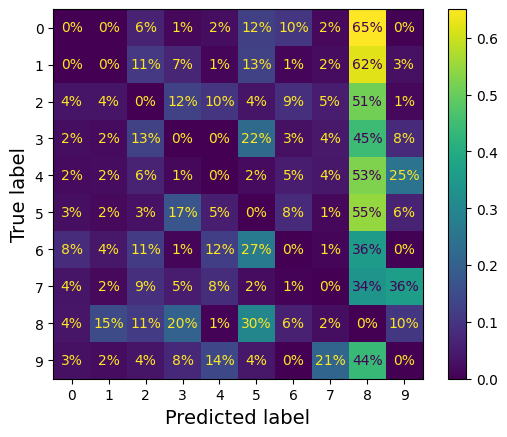

In [81]:
#Display confusion matrix with errors only
sample_weight = (y_train_pred != y_train)
plt.rc('font', size=10)  # extra code
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred,
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
plt.show()

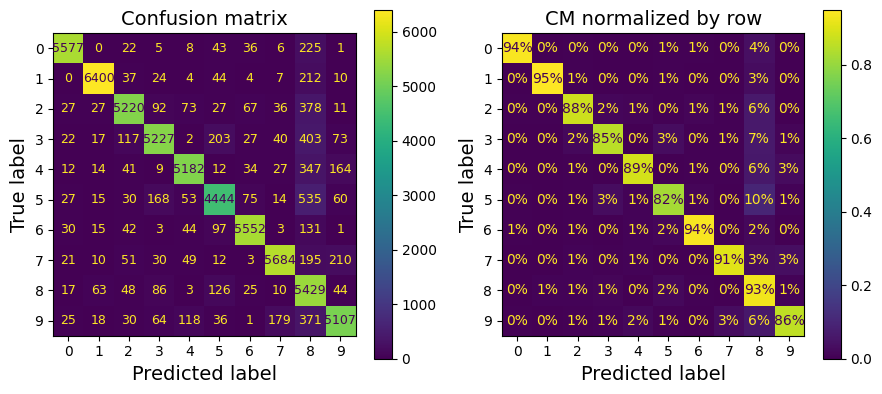

In [82]:
# this cell generates and saves Figure 3–9
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=9)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0])
axs[0].set_title("Confusion matrix")
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        normalize="true", values_format=".0%")
axs[1].set_title("CM normalized by row")
save_fig("confusion_matrix_plot_1")
plt.show()

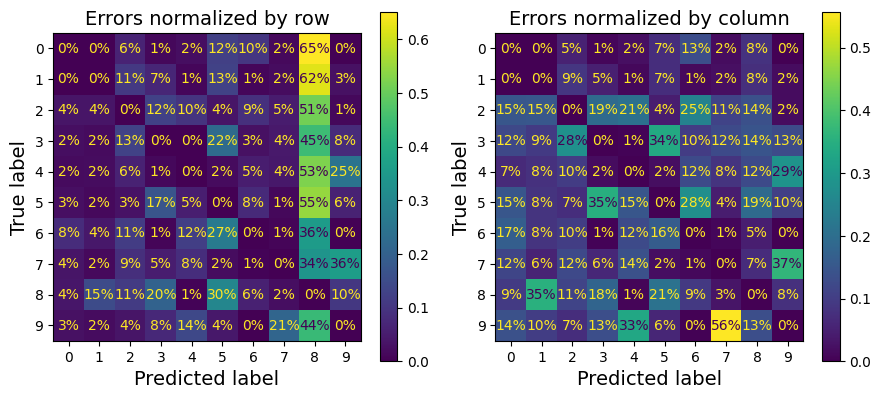

In [83]:
# this cell generates and saves Figure 3–10
fig, axs = plt.subplots(nrows=1, ncols=2, figsize=(9, 4))
plt.rc('font', size=10)
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[0],
                                        sample_weight=sample_weight,
                                        normalize="true", values_format=".0%")
axs[0].set_title("Errors normalized by row")
ConfusionMatrixDisplay.from_predictions(y_train, y_train_pred, ax=axs[1],
                                        sample_weight=sample_weight,
                                        normalize="pred", values_format=".0%")
axs[1].set_title("Errors normalized by column")
save_fig("confusion_matrix_plot_2")
plt.show()
plt.rc('font', size=14)  # make fonts great again

## Multilabel Classification

In [84]:
import numpy as np
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import f1_score

# Create a binary label indicating whether the digit is 7 or greater (large)
y_train_large = (y_train >= '7')

# Create a binary label indicating whether the digit is odd
y_train_odd = (y_train.astype('int8') % 2 == 1)

# Combine the two binary labels into a multilabel array
y_multilabel = np.c_[y_train_large, y_train_odd]

# Create an instance of the k-Nearest Neighbors classifier
knn_clf = KNeighborsClassifier()

# Train the k-Nearest Neighbors classifier on the training data with multilabels
knn_clf.fit(X_train, y_multilabel)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [85]:
# Predict the multilabels for 'some_digit' using the trained k-NN classifier
knn_clf.predict([some_digit])

array([[False,  True]])

In [86]:
# Perform cross-validation to obtain predictions for each instance in the training set
y_train_knn_pred = cross_val_predict(knn_clf, X_train, y_multilabel, cv=3)

# Calculate the F1 score for the multilabel classification
# 'average="macro"' computes the F1 score for each label and averages them
f1 = f1_score(y_multilabel, y_train_knn_pred, average="macro")
# Display the F1 score
print("F1 score:", f1)

F1 score: 0.9764102655606048


In [87]:
# Shows that we get a negligible performance improvement when we
#              set average="weighted" because the classes are already pretty
#              well balanced.
f1_score(y_multilabel, y_train_knn_pred, average="weighted")
# Display the F1 score
print("F1 score:", f1)

F1 score: 0.9764102655606048


ClassifierChain for multilabel classification on the MNIST dataset

In [88]:
from sklearn.multioutput import ClassifierChain

chain_clf = ClassifierChain(SVC(), cv=3, random_state=42)
chain_clf.fit(X_train[:2000], y_multilabel[:2000])

,estimator,SVC()
,order,None
,cv,3
,chain_method,'predict'
,random_state,42
,verbose,False
,base_estimator,'deprecated'
,C,1.0
,kernel,'rbf'
,degree,3
,gamma,'scale'


In [89]:
some_digit_prediction = chain_clf.predict([some_digit])
print("Predicted multilabels for 'some_digit':", some_digit_prediction)

Predicted multilabels for 'some_digit': [[0. 1.]]


## Multioutput Classification

In [90]:
import numpy as np
np.random.seed(42)  # Set the random seed for reproducibility

# Generate random noise and add it to the training data
# 'np.random.randint(0, 100, (len(X_train), 784))' generates random integers between 0 and 100
# The shape of the noise array matches the shape of the training data
noise = np.random.randint(0, 100, (len(X_train), 784))

X_train_mod = X_train + noise  # Add the generated noise to the training data

# Generate random noise and add it to the test data
# The shape of the noise array matches the shape of the test data
noise = np.random.randint(0, 100, (len(X_test), 784))
X_test_mod = X_test + noise  # Add the generated noise to the test data

# Set the targets for the modified data to be the original, noise-free data
# The goal is to predict the original images from the noisy images
y_train_mod = X_train
y_test_mod = X_test


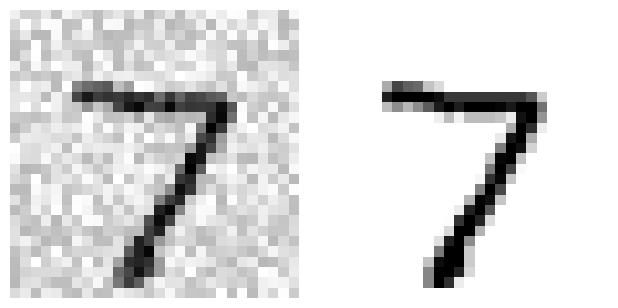

In [91]:
# This cell generates and saves Figure 3–12
plt.subplot(121); plot_digit(X_test_mod[0])
plt.subplot(122); plot_digit(y_test_mod[0])
save_fig("noisy_digit_example_plot")
plt.show()

#Displaying a noisy image (left) and a clean image (right)

#Train a k-Nearest Neighbors (k-NN) classifier on the noisy MNIST dataset

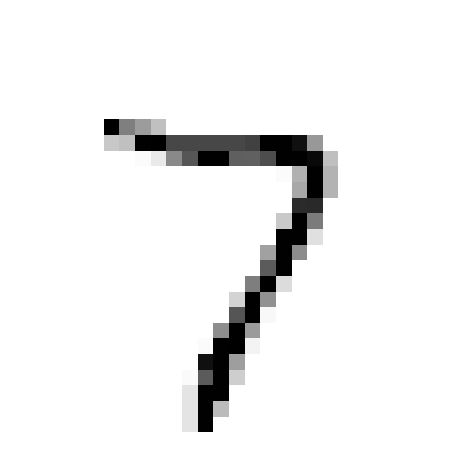

In [92]:
# Create an instance of the k-Nearest Neighbors classifier
knn_clf = KNeighborsClassifier()

# Train the k-Nearest Neighbors classifier on the modified training data
# 'X_train_mod' is the noisy training data
# 'y_train_mod' is the original, noise-free training data
knn_clf.fit(X_train_mod, y_train_mod)

# Predict the original image from the noisy test image using the trained k-NN classifier
# 'X_test_mod[0]' is the first noisy test image
clean_digit = knn_clf.predict([X_test_mod[0]])

# Plot the cleaned digit image
plot_digit(clean_digit)
save_fig("cleaned_digit_example_plot")  # extra code – saves Figure 3–13
plt.show()